We are going to build our first transformer model using keras . we will implement a simple transformer architecture for sequence-to-sequence tasks which in this case will be a text translation task.

In [102]:
# let's do some setup changes
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Disable oneDNN optimizations for TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow logging (1: INFO, 2: WARNING, 3: ERROR)

In [103]:
# block warnings
import warnings
warnings.filterwarnings('ignore')

In [104]:
from keras.models import Model
from keras.layers import Input, Dense, LSTM, Embedding, Dropout, Input , Layer, Concatenate
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras import backend as K
import numpy as np
import tensorflow as tf
from keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

In [105]:
# sample parallel sentences (English --> Spanish)
input_texts= [
    'Hello',
    'I am learning machine learning',
    'How are you?',
    'I love programming',
    'This is a test sentence',
    'Where is the library?',
    'I speak a little Spanish',
    'How much does it cost?',
    'I need help',
    'Good morning'
]

output_texts = [
    'Hola',
    'Estoy aprendiendo aprendizaje automático',
    '¿Cómo estás?',
    'Me gusta programar',
    'Esta es una oración de prueba',
    '¿Dónde está la biblioteca?',
    'Hablo un poco de español',
    '¿Cuánto cuesta?',
    'Necesito ayuda',
    'Buenos días'
]

### Adding More Sample Training Data

To further illustrate how to expand the dataset, here are a few more sample sentences that will be appended to the existing `input_texts` and `output_texts` lists. After running the cell below, **please re-execute all subsequent cells** (starting from tokenization, padding, and then model training) to ensure the model uses the updated dataset.

In [106]:
# Additional sample parallel sentences
new_input_texts = [
    'What is your name?',
    'I am hungry',
    'Can you help me?',
    'Thank you',
    'Where are you from?'
]

new_output_texts = [
    '¿Cuál es tu nombre?',
    'Tengo hambre',
    '¿Puedes ayudarme?',
    'Gracias',
    '¿De dónde eres?'
]

# Extend the existing lists
input_texts.extend(new_input_texts)
output_texts.extend(new_output_texts)

print(f"Total training samples: {len(input_texts)}")
print("Please re-run all subsequent data preprocessing and model training cells (from cell `e703faa2` onwards).")


Total training samples: 15
Please re-run all subsequent data preprocessing and model training cells (from cell `e703faa2` onwards).


In [107]:
# add start and end tokens to the output sentences
output_texts = ['startseq ' + text + ' endseq' for text in output_texts]
output_texts

['startseq Hola endseq',
 'startseq Estoy aprendiendo aprendizaje automático endseq',
 'startseq ¿Cómo estás? endseq',
 'startseq Me gusta programar endseq',
 'startseq Esta es una oración de prueba endseq',
 'startseq ¿Dónde está la biblioteca? endseq',
 'startseq Hablo un poco de español endseq',
 'startseq ¿Cuánto cuesta? endseq',
 'startseq Necesito ayuda endseq',
 'startseq Buenos días endseq',
 'startseq ¿Cuál es tu nombre? endseq',
 'startseq Tengo hambre endseq',
 'startseq ¿Puedes ayudarme? endseq',
 'startseq Gracias endseq',
 'startseq ¿De dónde eres? endseq']

In [108]:
# tokenie the input and output sentences
input_tokenizer = Tokenizer()
input_tokenized = input_tokenizer.fit_on_texts(input_texts)
input_sequence=input_tokenizer.texts_to_sequences(input_texts)

output_tokenizer = Tokenizer()
output_tokenizer.fit_on_texts(output_texts)
output_sequence = output_tokenizer.texts_to_sequences(output_texts)

input_vocab_size= len(input_tokenizer.word_index) + 1
output_vocab_size= len(output_tokenizer.word_index) + 1
output_sequence

[[1, 5, 2],
 [1, 6, 7, 8, 9, 2],
 [1, 10, 11, 2],
 [1, 12, 13, 14, 2],
 [1, 15, 3, 16, 17, 4, 18, 2],
 [1, 19, 20, 21, 22, 2],
 [1, 23, 24, 25, 4, 26, 2],
 [1, 27, 28, 2],
 [1, 29, 30, 2],
 [1, 31, 32, 2],
 [1, 33, 3, 34, 35, 2],
 [1, 36, 37, 2],
 [1, 38, 39, 2],
 [1, 40, 2],
 [1, 41, 42, 43, 2]]

In [109]:
output_tokenizer.word_index

{'startseq': 1,
 'endseq': 2,
 'es': 3,
 'de': 4,
 'hola': 5,
 'estoy': 6,
 'aprendiendo': 7,
 'aprendizaje': 8,
 'automático': 9,
 '¿cómo': 10,
 'estás': 11,
 'me': 12,
 'gusta': 13,
 'programar': 14,
 'esta': 15,
 'una': 16,
 'oración': 17,
 'prueba': 18,
 '¿dónde': 19,
 'está': 20,
 'la': 21,
 'biblioteca': 22,
 'hablo': 23,
 'un': 24,
 'poco': 25,
 'español': 26,
 '¿cuánto': 27,
 'cuesta': 28,
 'necesito': 29,
 'ayuda': 30,
 'buenos': 31,
 'días': 32,
 '¿cuál': 33,
 'tu': 34,
 'nombre': 35,
 'tengo': 36,
 'hambre': 37,
 '¿puedes': 38,
 'ayudarme': 39,
 'gracias': 40,
 '¿de': 41,
 'dónde': 42,
 'eres': 43}

In [110]:
# padding the input and output sequences to have the same length
max_input_length = max([len(seq) for seq in input_sequence])
max_output_length = max([len(seq) for seq in output_sequence])
input_sequence= pad_sequences(input_sequence , maxlen=max_input_length, padding='post')
output_sequence= pad_sequences(output_sequence , maxlen=max_output_length, padding='post')

# Ensure output_sequence is explicitly a NumPy array and print its shape for verification
output_sequence = np.array(output_sequence)
print("Shape of padded output_sequence:", output_sequence.shape)

Shape of padded output_sequence: (15, 8)


In [111]:
# prepare the decoder input and output
output_sequence_np = np.array(output_sequence)
decoder_input_sequence = output_sequence_np[:, :-1]
decoder_target_sequence = output_sequence_np[:, 1:]
decoder_output_data = np.array([np.eye(output_vocab_size)[seq] for seq in decoder_target_sequence])
decoder_input_sequence , decoder_target_sequence,decoder_output_data

(array([[ 1,  5,  2,  0,  0,  0,  0],
        [ 1,  6,  7,  8,  9,  2,  0],
        [ 1, 10, 11,  2,  0,  0,  0],
        [ 1, 12, 13, 14,  2,  0,  0],
        [ 1, 15,  3, 16, 17,  4, 18],
        [ 1, 19, 20, 21, 22,  2,  0],
        [ 1, 23, 24, 25,  4, 26,  2],
        [ 1, 27, 28,  2,  0,  0,  0],
        [ 1, 29, 30,  2,  0,  0,  0],
        [ 1, 31, 32,  2,  0,  0,  0],
        [ 1, 33,  3, 34, 35,  2,  0],
        [ 1, 36, 37,  2,  0,  0,  0],
        [ 1, 38, 39,  2,  0,  0,  0],
        [ 1, 40,  2,  0,  0,  0,  0],
        [ 1, 41, 42, 43,  2,  0,  0]], dtype=int32),
 array([[ 5,  2,  0,  0,  0,  0,  0],
        [ 6,  7,  8,  9,  2,  0,  0],
        [10, 11,  2,  0,  0,  0,  0],
        [12, 13, 14,  2,  0,  0,  0],
        [15,  3, 16, 17,  4, 18,  2],
        [19, 20, 21, 22,  2,  0,  0],
        [23, 24, 25,  4, 26,  2,  0],
        [27, 28,  2,  0,  0,  0,  0],
        [29, 30,  2,  0,  0,  0,  0],
        [31, 32,  2,  0,  0,  0,  0],
        [33,  3, 34, 35,  2,  0,  0

In [112]:
class SelfAttention(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        # input_shape is a list: [q_shape, k_shape, v_shape]
        feature_dim = input_shape[0][-1]

        self.Wq = self.add_weight(
            shape=(feature_dim, feature_dim),
            initializer='glorot_uniform',
            trainable=True,
            name='Wq'
        )

        self.Wk = self.add_weight(
            shape=(feature_dim, feature_dim),
            initializer='glorot_uniform',
            trainable=True,
            name='Wk'
        )

        self.Wv = self.add_weight(
            shape=(feature_dim, feature_dim),
            initializer='glorot_uniform',
            trainable=True,
            name='Wv'
        )

        super(SelfAttention, self).build(input_shape)

    def call(self, inputs):
        # Expect list: [query, key, value]
        q, k, v = inputs

        q = tf.matmul(q, self.Wq)
        k = tf.matmul(k, self.Wk)
        v = tf.matmul(v, self.Wv)

        # Scaled dot-product attention
        scores = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], dtype=tf.float32)
        scores = scores / tf.sqrt(dk)

        attention_weights = tf.nn.softmax(scores, axis=-1)
        output = tf.matmul(attention_weights, v)

        return output

In [113]:
# Encoder
encoder_inputs = Input(shape=(max_input_length,))
encoder_embedding = Embedding(input_vocab_size, 128)(encoder_inputs)
encoder_lstm = LSTM(128, return_sequences=True, return_state=True, kernel_regularizer=l2(0.001), activity_regularizer=l2(0.001))
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]
encoder_outputs = Dropout(0.5)(encoder_outputs) # Add dropout to encoder outputs

# Decoder
decoder_inputs = Input(shape=(max_output_length - 1,))
decoder_embedding = Embedding(output_vocab_size, 128)(decoder_inputs)
decoder_lstm = LSTM(128, return_sequences=True, return_state=True, kernel_regularizer=l2(0.001), activity_regularizer=l2(0.001))
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)
decoder_outputs = Dropout(0.5)(decoder_outputs) # Add dropout to decoder outputs

# Attention: decoder attends to encoder outputs
self_attention = SelfAttention()
attention_output = self_attention(
    [decoder_outputs, encoder_outputs, encoder_outputs]
)


# Combine decoder outputs with attention context
decoder_concat = Concatenate(axis=-1)([decoder_outputs, attention_output])

# Final Dense layer
decoder_dense = Dense(output_vocab_size, activation='softmax', kernel_regularizer=l2(0.001), activity_regularizer=l2(0.001))
decoder_outputs = decoder_dense(decoder_concat)

# Full Model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary
model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_23      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_24      │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_20        │ (None, 5, 128)    │      4,864 │ input_layer_23[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_21        │ (None, 7, 128)    │      5,632 │ input_layer_24[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_20 (LSTM)      │ [(None, 5, 128),  │    131,584 │ embedding_20[0][… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_21 (LSTM)      │ [(None, 7, 128),  │    131,584 │ embedding_21[0][… │
│                     │ (None, 128),      │            │ lstm_20[0][1],    │
│                     │ (None, 128)]      │            │ lstm_20[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 7, 128)    │          0 │ lstm_21[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 5, 128)    │          0 │ lstm_20[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention_10   │ (None, 7, 128)    │     49,152 │ dropout_13[0][0], │
│ (SelfAttention)     │                   │            │ dropout_12[0][0], │
│                     │                   │            │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 7, 256)    │          0 │ dropout_13[0][0], │
│ (Concatenate)       │                   │            │ self_attention_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 7, 44)     │     11,308 │ concatenate_9[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 334,124 (1.27 MB)

 Trainable params: 334,124 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [114]:
# Define EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=15, mode='min', restore_best_weights=True)

# train the model with EarlyStopping
history = model.fit([input_sequence, decoder_input_sequence], np.array(decoder_output_data), batch_size=32, epochs=100, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.0238 - loss: 4.2722 - val_accuracy: 0.5714 - val_loss: 4.2285
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.4048 - loss: 4.2402 - val_accuracy: 0.5714 - val_loss: 4.1891
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.4167 - loss: 4.2028 - val_accuracy: 0.5714 - val_loss: 4.1472
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.4167 - loss: 4.1683 - val_accuracy: 0.5714 - val_loss: 4.1014
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.4167 - loss: 4.1301 - val_accuracy: 0.5714 - val_loss: 4.0499
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.4167 - loss: 4.0877 - val_accuracy: 0.5714 - val_loss: 3.9908
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.4167 - loss: 4.0364 - val_accuracy: 0.5714 - val_loss: 3.9215
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.4167 - loss: 3.9887 - val_accuracy: 0.5714 - val_

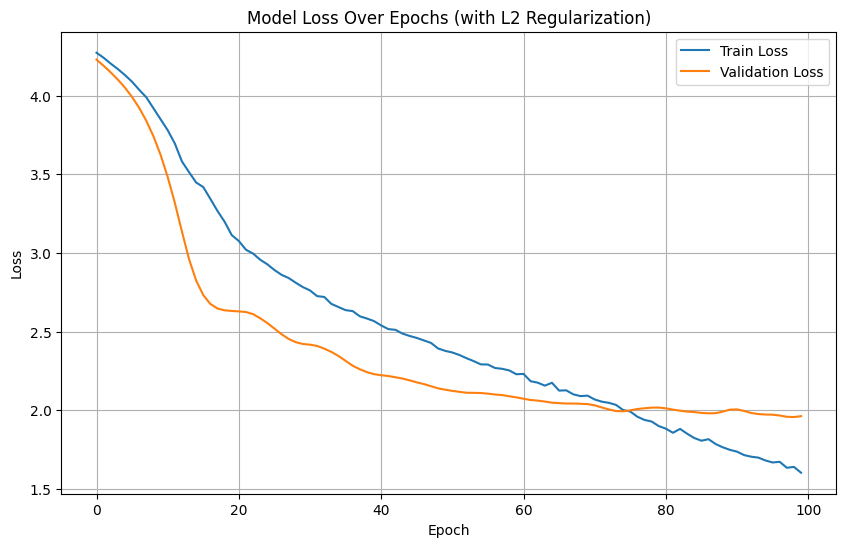

In [115]:
# PLOT the loss
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs (with L2 Regularization)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()